In [107]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

class LaneDetector:
    def __init__(self, target_height=480):
        self.target_height = target_height

    def resize_preserve_aspect(self, image, target_height=None):
        if target_height is None:
            target_height = self.target_height
        h, w = image.shape[:2]
        aspect_ratio = w / h
        target_width = int(target_height * aspect_ratio)
        resized = cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)
        return resized

    def remove_green_regions(self, image, green_threshold=40, region_density_threshold=0.5):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([60 - green_threshold, 40, 40])
        upper_green = np.array([60 + green_threshold, 255, 255])
        green_mask = cv2.inRange(hsv, lower_green, upper_green)
        kernel_size = 15
        density = cv2.blur(green_mask.astype(np.float32)/255, (kernel_size, kernel_size))
        region_mask = (density >= region_density_threshold).astype(np.uint8) * 255
        region_mask = cv2.morphologyEx(region_mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
        combined_mask = cv2.bitwise_or(green_mask, region_mask)
        result = image.copy()
        result[combined_mask > 0] = [0, 0, 0]
        return result, green_mask, region_mask

    def gray_eq(self, img):
        img_rgb = img[..., :3]
        gray_image = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        equalized = cv2.equalizeHist(gray_image)
        gray_image = equalized.astype(np.float32) / 255.0
        gray_image = np.clip((gray_image - 0.25) / (1.0 - 0.25), 0, 1)
        return gray_image

    def canny_edge_detection(self, blurred, low_thresh=0.1, high_thresh=0.2):
        blurred_uint8 = (blurred * 255).astype(np.uint8)
        low_trsh = int(low_thresh * 255)
        high_trsh = int(high_thresh * 255)
        edges = cv2.Canny(blurred_uint8, threshold1=low_trsh, threshold2=high_trsh)
        edges = edges.astype(bool)
        return edges

    def apply_roi_mask_to_edges(self, edges, trapezoid_vertices):
        mask = np.zeros_like(edges, dtype=np.uint8)
        polygon = np.array([trapezoid_vertices], dtype=np.int32)
        cv2.fillPoly(mask, polygon, color=1)
        return edges & (mask.astype(bool))

    def average_direction(self, p0, p1):
        dx = p1[0] - p0[0]
        dy = p1[1] - p0[1]
        return np.degrees(np.arctan2(dy, dx))

    def line_midpoint(self, p0, p1):
        return ((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2)

    def group_similar_lines(self, lines, angle_thresh=5, x_thresh=10):
        groups = []
        for line in lines:
            p0, p1 = line
            angle = self.average_direction(p0, p1)
            midpoint = self.line_midpoint(p0, p1)
            matched = False
            for group in groups:
                ga, gm = group['angle'], group['midpoint']
                if abs(angle - ga) < angle_thresh and abs(midpoint[0] - gm[0]) < x_thresh:
                    group['lines'].append(line)
                    group['angle'] = (group['angle'] + angle) / 2
                    group['midpoint'] = ((group['midpoint'][0] + midpoint[0]) / 2,
                                         (group['midpoint'][1] + midpoint[1]) / 2)
                    matched = True
                    break
            if not matched:
                groups.append({'angle': angle, 'midpoint': midpoint, 'lines': [line]})
        return groups

    def fit_line_through_group(self, group_lines):
        points = []
        for p0, p1 in group_lines:
            points.extend([p0, p1])
        points = np.array(points)
        xs, ys = points[:, 0], points[:, 1]
        if len(xs) < 2:
            return None
        poly = np.polyfit(xs, ys, deg=1)
        return poly

    def compute_intersection(self, poly1, poly2):
        m1, b1 = poly1
        m2, b2 = poly2
        if m1 == m2:
            return None
        x = (b2 - b1) / (m1 - m2)
        y = m1 * x + b1
        return (x, y)

    def extrapolate_line(self, poly, y1, y2):
        m, b = poly
        x1 = (y1 - b) / m
        x2 = (y2 - b) / m
        return (x1, y1), (x2, y2)
    

    def get_trapezoid_vertices(self, h, w, camera_type='google_maps'):
        # Google maps trapezoid for lane detection
        trapezoid_google = np.array([
            (int(w * 0.25), int(h)),
            (int(w * 0.45), int(h * 0.65)),
            (int(w * 0.55), int(h * 0.65)),
            (int(w * 0.75), int(h)),
        ], dtype=np.int32)

        # Iphone camera trapezoid for lane detection
        trapezoid_iphone = np.array([
            (int(w * 0.1), int(h)),
            (int(w * 0.45), int(h * 0.6)),
            (int(w * 0.55), int(h * 0.6)),
            (int(w * 0.9), int(h)),
        ], dtype=np.int32)

        trapezoid = None
        if camera_type == 'google_maps':
            trapezoid = trapezoid_google
        elif camera_type == 'iphone':
            trapezoid = trapezoid_iphone
        if trapezoid is None:
            raise ValueError("Invalid camera_type provided. Must be 'google_maps' or 'iphone'.")
        
        return trapezoid



# -----------------------------------------------------------------------------------------------

    def detect_lanes_from_file(self, img_path, camera_type='google_maps'):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.resize_preserve_aspect(img, target_height=self.target_height)

        green_removed, green_mask, region_mask = self.remove_green_regions(
            img, green_threshold=35, region_density_threshold=0.48)

        gray_image = self.gray_eq(green_removed)
        blurred = cv2.GaussianBlur(gray_image, (0, 0), sigmaX=2.5, sigmaY=2.5)
        canny_edges = self.canny_edge_detection(blurred)

        h, w = canny_edges.shape

        trapezoid = self.get_trapezoid_vertices(h, w, camera_type=camera_type)
        edges_roi = self.apply_roi_mask_to_edges(canny_edges, trapezoid)

        edges_uint8 = (edges_roi.astype(np.uint8)) * 255
        raw_lines = cv2.HoughLinesP(
            edges_uint8,
            rho=1,
            theta=np.pi / 180,
            threshold=10,
            minLineLength=25,
            maxLineGap=5
        )

        lines = []
        if raw_lines is not None:
            for line in raw_lines:
                x1, y1, x2, y2 = line[0]
                lines.append(((x1, y1), (x2, y2)))

        angle_min = 23
        angle_max = 150

        filtered_lines = []
        for p0, p1 in lines:
            dx = p1[0] - p0[0]
            dy = p1[1] - p0[1]
            angle = np.degrees(np.arctan2(dy, dx))
            if angle_min < abs(angle) < angle_max:
                filtered_lines.append((p0, p1))

        image_center_x = img.shape[1] // 2
        left_lines = []
        right_lines = []
        for p0, p1 in filtered_lines:
            x_avg = (p0[0] + p1[0]) / 2
            if x_avg < image_center_x:
                left_lines.append((p0, p1))
            else:
                right_lines.append((p0, p1))

        left_group = self.group_similar_lines(left_lines)
        right_group = self.group_similar_lines(right_lines)
        best_left = max(left_group, key=lambda g: len(g['lines']), default=None)
        best_right = max(right_group, key=lambda g: len(g['lines']), default=None)
        left_fit = self.fit_line_through_group(best_left['lines']) if best_left else None
        right_fit = self.fit_line_through_group(best_right['lines']) if best_right else None

        height = img.shape[0]
        output_img = img.copy()
        height = img.shape[0]

        if (left_fit is not None) and (right_fit is not None):
            bottom_y = height
            top_y_default = int(height * 0.6)
            intersection = self.compute_intersection(left_fit, right_fit)
            if intersection and intersection[1] > top_y_default:
                top_y = int(intersection[1])
            else:
                top_y = int(top_y_default)

            l0, l1 = self.extrapolate_line(left_fit, bottom_y, top_y)
            r0, r1 = self.extrapolate_line(right_fit, bottom_y, top_y)

        
            overlay = output_img.copy()
            polygon_pts = np.array([l0, l1, r1, r0], dtype=np.int32)
            cv2.fillPoly(overlay, [polygon_pts], color=(0,255,0))

            alpha = 0.35
            cv2.addWeighted(overlay, alpha, output_img, 1 - alpha, 0, output_img)

        
            cv2.line(output_img, tuple(map(int, l0)), tuple(map(int, l1)), (220,0,0), 2)
            cv2.line(output_img, tuple(map(int, r0)), tuple(map(int, r1)), (0,15,180), 2)


        return {
            "img": img,
            "green_removed": green_removed,
            "green_mask": green_mask,
            "region_mask": region_mask,
            "gray_image": gray_image,
            "blurred": blurred,
            "canny_edges": canny_edges,
            "edges_roi": edges_roi,
            "lines": lines,
            "filtered_lines": filtered_lines,
            "left_fit": left_fit,
            "right_fit": right_fit,
            "output_image": output_img,
        }
        


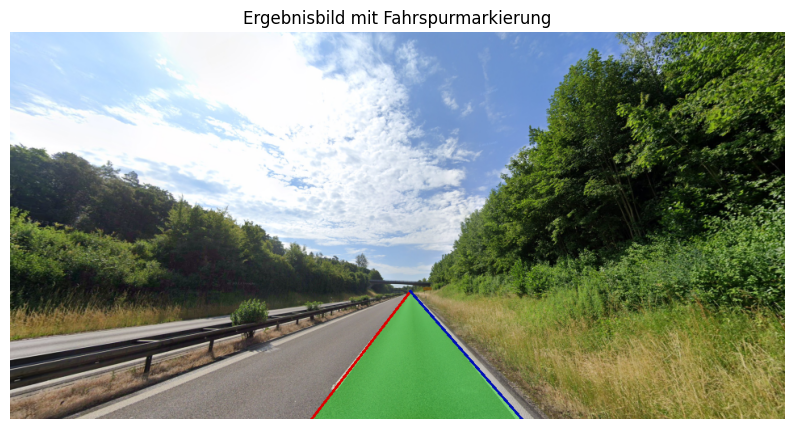

In [108]:
detector = LaneDetector(target_height=480)
result = detector.detect_lanes_from_file("img/img1.png", camera_type='google_maps')
output_img = result["output_image"]

# Optional: Visualisierung des Ergebnisses
plt.figure(figsize=(10, 10))
plt.imshow(output_img)
plt.title("Ergebnisbild mit Fahrspurmarkierung")
plt.axis('off')
plt.show()

# Bild abspeichern
#output_bgr = cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR)
#cv2.imwrite("output_lane.png", output_bgr)


In [105]:
import cv2
from tqdm import tqdm

def process_video_with_lane_detector(detector, input_video_path, output_video_path, camera_type='iphone'):
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("Video konnte nicht gelesen werden")
    # Frame einmal durch Pipeline für Größe
    cv2.imwrite("__temp_first_frame.png", frame)
    result = detector.detect_lanes_from_file("__temp_first_frame.png", camera_type=camera_type)
    output_img = result["output_image"]
    h, w = output_img.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for _ in tqdm(range(total), desc="Frames"):
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite("__temp.png", frame)
        result = detector.detect_lanes_from_file("__temp.png", camera_type=camera_type)
        output_img = result["output_image"]
        out.write(cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))
    cap.release()
    out.release()
    import os; os.remove("__temp.png"); os.remove("__temp_first_frame.png")


In [ ]:
detector = LaneDetector(target_height=480)
process_video_with_lane_detector(detector, "img/KN_Mainau.mp4", "output.mp4")